# Kalp Hastalığı Tahmini

Bu projede, klinik veriler kullanılarak bir kişide kalp hastalığı riski olup olmadığı makine öğrenmesi yöntemleriyle tahmin edilmiştir.

## Proje Adımları

1. Veri setinin incelenmesi
2. Eksik verilerin analizi ve hazırlanması
3. Özelliklerin dönüştürülmesi
4. Birden fazla makine öğrenmesi modelinin eğitilmesi
5. Modellerin performans karşılaştırması
6. Nihai modelin kaydedilmesi

In [1]:
import pandas as pd
import numpy as np

In [2]:

DATA_PATH = "../data/heart_disease_uci.csv"

In [3]:

df = pd.read_csv(DATA_PATH)


In [4]:

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
df.shape

(920, 16)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


In [7]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [8]:
df["target"] = (df["num"] > 0).astype(int)

df["target"].value_counts()

target
1    509
0    411
Name: count, dtype: int64

In [9]:
missing = (df.isnull().mean() * 100).sort_values(ascending=False)

missing

ca          66.413043
thal        52.826087
slope       33.586957
fbs          9.782609
oldpeak      6.739130
trestbps     6.413043
exang        5.978261
thalch       5.978261
chol         3.260870
restecg      0.217391
id           0.000000
dataset      0.000000
cp           0.000000
age          0.000000
sex          0.000000
num          0.000000
target       0.000000
dtype: float64

In [10]:
# Kullanmayacağımız sütunlar
drop_cols = ["id", "num", "ca", "thal", "slope"]

df_model = df.drop(columns=drop_cols)

df_model.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,target
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0


In [11]:
X = df_model.drop(columns="target")
y = df_model["target"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string", "bool"]).columns.tolist()

print("Sayısal sütunlar:", numeric_features)
print("Kategorik sütunlar:", categorical_features)

Sayısal sütunlar: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Kategorik sütunlar: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang']


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.837

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.79      0.81        82
           1       0.84      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184

Confusion Matrix:
 [[65 17]
 [13 89]]


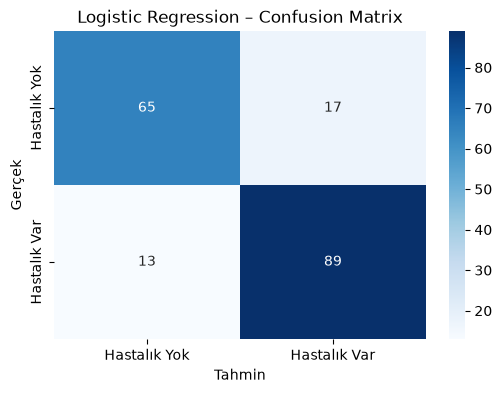

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Hastalık Yok", "Hastalık Var"],
    yticklabels=["Hastalık Yok", "Hastalık Var"]
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Logistic Regression – Confusion Matrix")
plt.show()

## Model Sonucu

Logistic Regression modeli test verisinde %83.7 doğruluk elde etti.

Model, kalp hastalığı bulunan 102 kişinin 89’unu doğru tahmin etti.
Bu sonuç, modelin hastalık vakalarını yakalama başarısının yaklaşık %87 olduğunu göstermektedir.

İlerleyen aşamada Random Forest gibi farklı modeller denenerek performans karşılaştırması yapılabilir.

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.837

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        82
           1       0.85      0.85      0.85       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184

Confusion Matrix:
 [[67 15]
 [15 87]]


## Model Karşılaştırması

Logistic Regression ve Random Forest modelleri test verisinde %83.7 doğruluk elde etti.

Ancak Logistic Regression, kalp hastalığı bulunan kişileri yakalamada %87 recall değeri ile Random Forest'ın (%85) önüne geçti. Bu nedenle proje için ana model olarak Logistic Regression seçilmiştir.

,feature,coefficient,absolute_coefficient
9,cat__dataset_Switzerland,1.921586,1.921586
11,cat__cp_asymptomatic,1.022782,1.022782
7,cat__dataset_Cleveland,-0.823731,0.823731
12,cat__cp_atypical angina,-0.823621,0.823621
8,cat__dataset_Hungary,-0.772220,0.772220
6,cat__sex_Male,0.667858,0.667858
4,num__oldpeak,0.610594,0.610594
21,cat__exang_True,0.564304,0.564304
5,cat__sex_Female,-0.562149,0.562149
20,cat__exang_False,-0.458595,0.458595


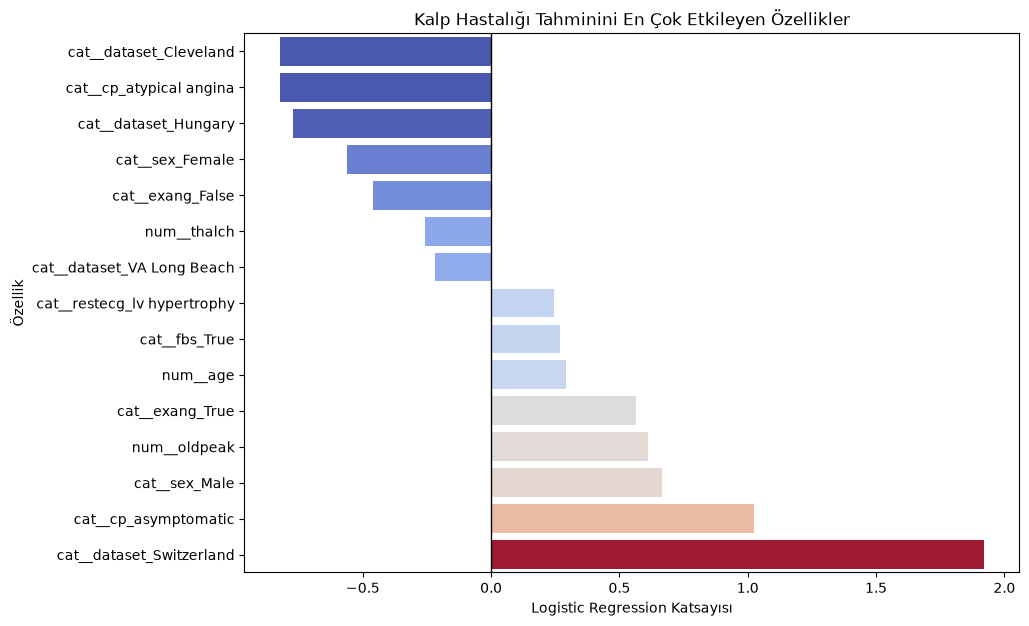

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dönüşüm sonrası oluşan tüm özellik isimleri
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Logistic Regression katsayıları
coefficients = model.named_steps["classifier"].coef_[0]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": abs(coefficients)
}).sort_values("absolute_coefficient", ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(10, 7))

top_features = importance_df.head(15).sort_values("coefficient")

sns.barplot(
    data=top_features,
    x="coefficient",
    y="feature",
    hue="coefficient",
    palette="coolwarm",
    legend=False
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Kalp Hastalığı Tahminini En Çok Etkileyen Özellikler")
plt.xlabel("Logistic Regression Katsayısı")
plt.ylabel("Özellik")
plt.show()

In [16]:
# dataset sütununu çıkararak yeni giriş verisini oluşturuyoruz
X_no_dataset = X.drop(columns="dataset")

numeric_features_no_dataset = X_no_dataset.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_no_dataset = X_no_dataset.select_dtypes(
    include=["object", "string", "bool"]
).columns.tolist()

X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_no_dataset,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor_nd = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_no_dataset),
        ("cat", categorical_transformer, categorical_features_no_dataset)
    ]
)

model_no_dataset = Pipeline(steps=[
    ("preprocessor", preprocessor_nd),
    ("classifier", LogisticRegression(max_iter=1000))
])

model_no_dataset.fit(X_train_nd, y_train_nd)

y_pred_nd = model_no_dataset.predict(X_test_nd)

print("Dataset sütunu olmadan Accuracy:", round(accuracy_score(y_test_nd, y_pred_nd), 3))
print("\nClassification Report:\n")
print(classification_report(y_test_nd, y_pred_nd))
print("Confusion Matrix:\n", confusion_matrix(y_test_nd, y_pred_nd))

Dataset sütunu olmadan Accuracy: 0.826

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.76      0.79        82
           1       0.82      0.88      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.82       184

Confusion Matrix:
 [[62 20]
 [12 90]]


ROC-AUC Score: 0.907


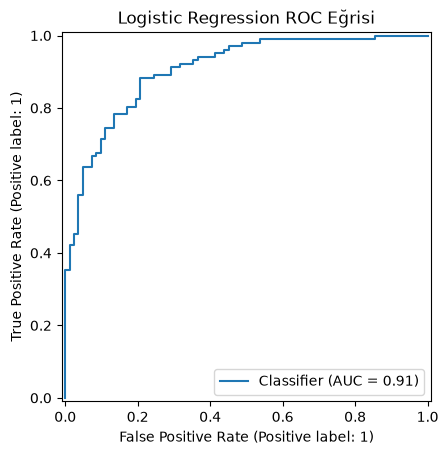

In [17]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Hastalık olasılıkları
y_prob_nd = model_no_dataset.predict_proba(X_test_nd)[:, 1]

# ROC-AUC skoru
auc_score = roc_auc_score(y_test_nd, y_prob_nd)

print("ROC-AUC Score:", round(auc_score, 3))

# ROC eğrisi
RocCurveDisplay.from_predictions(y_test_nd, y_prob_nd)
plt.title("Logistic Regression ROC Eğrisi")
plt.show()

In [18]:
from pathlib import Path
import joblib

models_folder = Path("../models")
models_folder.mkdir(exist_ok=True)

model_path = models_folder / "heart_disease_model.joblib"

joblib.dump(model_no_dataset, model_path)

print(f"Model başarıyla kaydedildi: {model_path.resolve()}")

Model başarıyla kaydedildi: C:\Users\info\Desktop\heart-disease-ml\models\heart_disease_model.joblib


In [19]:
loaded_model = joblib.load("../models/heart_disease_model.joblib")

new_patient = pd.DataFrame([{
    "age": 55,
    "sex": "Male",
    "cp": "asymptomatic",
    "trestbps": 140,
    "chol": 250,
    "fbs": False,
    "restecg": "normal",
    "thalch": 150,
    "exang": True,
    "oldpeak": 2.0
}])

prediction = loaded_model.predict(new_patient)[0]
probability = loaded_model.predict_proba(new_patient)[0][1]

print("Tahmin:", "Kalp hastalığı riski var" if prediction == 1 else "Kalp hastalığı riski yok")
print(f"Hastalık olasılığı: %{probability * 100:.1f}")

Tahmin: Kalp hastalığı riski var
Hastalık olasılığı: %88.9


In [20]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    model_no_dataset,
    X_no_dataset,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

cv_results = pd.DataFrame({
    "Accuracy": scores["test_accuracy"],
    "Precision": scores["test_precision"],
    "Recall": scores["test_recall"],
    "F1 Score": scores["test_f1"],
    "ROC-AUC": scores["test_roc_auc"]
})

display(cv_results)

print("\nOrtalama sonuçlar:")
print(cv_results.mean().round(3))

print("\nStandart sapma:")
print(cv_results.std().round(3))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.831522,0.812500,0.900990,0.854460,0.898485
1,0.809783,0.838384,0.813725,0.825871,0.900526
2,0.798913,0.809524,0.833333,0.821256,0.883429
3,0.755435,0.787879,0.764706,0.776119,0.852224
4,0.809783,0.813084,0.852941,0.832536,0.882114



Ortalama sonuçlar:
Accuracy     0.801
Precision    0.812
Recall       0.833
F1 Score     0.822
ROC-AUC      0.883
dtype: float64

Standart sapma:
Accuracy     0.028
Precision    0.018
Recall       0.050
F1 Score     0.029
ROC-AUC      0.019
dtype: float64


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Test kümesindeki hastalık olasılıkları
y_prob_nd = model_no_dataset.predict_proba(X_test_nd)[:, 1]

# Varsayılan eşik: %50
y_pred_50 = (y_prob_nd >= 0.50).astype(int)

# Daha hassas eşik: %40
y_pred_40 = (y_prob_nd >= 0.40).astype(int)

comparison = pd.DataFrame({
    "Eşik": ["%50", "%40"],
    "Accuracy": [
        accuracy_score(y_test_nd, y_pred_50),
        accuracy_score(y_test_nd, y_pred_40)
    ],
    "Precision": [
        precision_score(y_test_nd, y_pred_50),
        precision_score(y_test_nd, y_pred_40)
    ],
    "Recall": [
        recall_score(y_test_nd, y_pred_50),
        recall_score(y_test_nd, y_pred_40)
    ],
    "F1 Score": [
        f1_score(y_test_nd, y_pred_50),
        f1_score(y_test_nd, y_pred_40)
    ]
}).round(3)

display(comparison)

print("Eşik %50 karışıklık matrisi:")
print(confusion_matrix(y_test_nd, y_pred_50))

print("\nEşik %40 karışıklık matrisi:")
print(confusion_matrix(y_test_nd, y_pred_40))

,Eşik,Accuracy,Precision,Recall,F1 Score
0,%50,0.826,0.818,0.882,0.849
1,%40,0.810,0.782,0.912,0.842


Eşik %50 karışıklık matrisi:
[[62 20]
 [12 90]]

Eşik %40 karışıklık matrisi:
[[56 26]
 [ 9 93]]


In [22]:
from sklearn.base import clone
import joblib

# Daha önce değerlendirdiğimiz pipeline'ın aynısını kullanıyoruz
final_model = clone(model_no_dataset)

# Tüm veriyle son eğitim
final_model.fit(X_no_dataset, y)

# Nihai modeli kaydet
final_model_path = "../models/heart_disease_final_model.joblib"
joblib.dump(final_model, final_model_path)

print("Nihai model kaydedildi:", final_model_path)

Nihai model kaydedildi: ../models/heart_disease_final_model.joblib


In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV

# Naive Bayes için dönüşmüş veriyi yoğun (dense) formata çeviriyoruz
to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x
)

models = {
    "KNN": Pipeline(steps=[
        ("preprocessor", preprocessor_nd),
        ("classifier", KNeighborsClassifier(n_neighbors=7))
    ]),

    "SVM": Pipeline(steps=[
        ("preprocessor", preprocessor_nd),
        ("classifier", CalibratedClassifierCV(
            estimator=SVC(kernel="rbf", random_state=42),
            method="sigmoid",
            cv=5,
            ensemble=False
        ))
    ]),
    
    "Naive Bayes": Pipeline(steps=[
        ("preprocessor", preprocessor_nd),
        ("dense", to_dense),
        ("classifier", GaussianNB())
    ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor_nd),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=5,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_nd),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "ANN (MLP)": Pipeline(steps=[
        ("preprocessor", preprocessor_nd),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            max_iter=1000,
            early_stopping=True,
            random_state=42
        ))
    ])
}

results = []

for name, current_model in models.items():
    current_model.fit(X_train_nd, y_train_nd)

    predictions = current_model.predict(X_test_nd)
    probabilities = current_model.predict_proba(X_test_nd)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_nd, predictions),
        "Precision": precision_score(y_test_nd, predictions),
        "Recall": recall_score(y_test_nd, predictions),
        "F1 Score": f1_score(y_test_nd, predictions),
        "ROC-AUC": roc_auc_score(y_test_nd, probabilities)
    })

comparison_df = pd.DataFrame(results).sort_values(
    by="ROC-AUC",
    ascending=False
).round(3)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,Random Forest,0.810,0.825,0.833,0.829,0.921
2,Naive Bayes,0.832,0.845,0.853,0.849,0.909
1,SVM,0.826,0.818,0.882,0.849,0.905
0,KNN,0.842,0.841,0.882,0.861,0.884
3,Decision Tree,0.783,0.804,0.804,0.804,0.851
5,ANN (MLP),0.554,0.554,1.000,0.713,0.397


In [24]:
ann_model = Pipeline(steps=[
    ("preprocessor", preprocessor_nd),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        solver="lbfgs",
        alpha=0.01,
        max_iter=2000,
        random_state=42
    ))
])

ann_model.fit(X_train_nd, y_train_nd)

ann_pred = ann_model.predict(X_test_nd)
ann_prob = ann_model.predict_proba(X_test_nd)[:, 1]

print("ANN Accuracy:", round(accuracy_score(y_test_nd, ann_pred), 3))
print("ANN Recall:", round(recall_score(y_test_nd, ann_pred), 3))
print("ANN F1 Score:", round(f1_score(y_test_nd, ann_pred), 3))
print("ANN ROC-AUC:", round(roc_auc_score(y_test_nd, ann_prob), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_nd, ann_pred))

ANN Accuracy: 0.75
ANN Recall: 0.824
ANN F1 Score: 0.785
ANN ROC-AUC: 0.777

Confusion Matrix:
 [[54 28]
 [18 84]]


In [25]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Eski başarısız ANN yerine iyileştirilmiş modeli ekle
models["ANN (MLP)"] = ann_model

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_comparison = []

for name, current_model in models.items():
    scores = cross_validate(
        current_model,
        X_no_dataset,
        y,
        cv=cv,
        scoring=["accuracy", "recall", "f1", "roc_auc"]
    )

    cv_comparison.append({
        "Model": name,
        "Accuracy Ortalama": scores["test_accuracy"].mean(),
        "Recall Ortalama": scores["test_recall"].mean(),
        "F1 Ortalama": scores["test_f1"].mean(),
        "ROC-AUC Ortalama": scores["test_roc_auc"].mean()
    })

cv_comparison_df = pd.DataFrame(cv_comparison).sort_values(
    "ROC-AUC Ortalama",
    ascending=False
).round(3)

display(cv_comparison_df)

,Model,Accuracy Ortalama,Recall Ortalama,F1 Ortalama,ROC-AUC Ortalama
1,SVM,0.805,0.870,0.831,0.885
2,Naive Bayes,0.801,0.817,0.820,0.882
4,Random Forest,0.820,0.831,0.836,0.880
0,KNN,0.818,0.861,0.840,0.869
3,Decision Tree,0.766,0.764,0.783,0.837
5,ANN (MLP),0.729,0.756,0.755,0.771


In [26]:
from sklearn.base import clone
import joblib

final_knn_model = clone(models["KNN"])

# Tüm 920 kayıtla nihai eğitim
final_knn_model.fit(X_no_dataset, y)

# Ayrı bir nihai model dosyası
final_knn_path = "../models/heart_disease_knn_final_model.joblib"

joblib.dump(final_knn_model, final_knn_path)

print("KNN nihai modeli kaydedildi:", final_knn_path)

KNN nihai modeli kaydedildi: ../models/heart_disease_knn_final_model.joblib


## Sonuç

Projede KNN, SVM, Naive Bayes, Decision Tree, Random Forest ve ANN modelleri karşılaştırılmıştır.

KNN modeli, %86.1 ortalama recall ve 0.840 F1 skoru ile kalp hastalığı vakalarını yakalama açısından en başarılı model seçilmiştir.

SVM modeli 0.885 ortalama ROC-AUC değeri ile sınıfları ayırma becerisinde en iyi sonucu vermiştir.

Nihai KNN modeli tüm veriyle eğitilmiş ve `models/heart_disease_knn_final_model.joblib` dosyasına kaydedilmiştir.

> Bu proje eğitim amaçlıdır; tıbbi tanı veya klinik karar desteği olarak kullanılmamalıdır.